In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
%matplotlib inline

In [3]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)
df.head()

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


In [4]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [5]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [24]:
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': np.float64(-3.4393644334758475), '5%': np.float64(-2.8655182850048306), '10%': np.float64(-2.568888486973192)}


<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

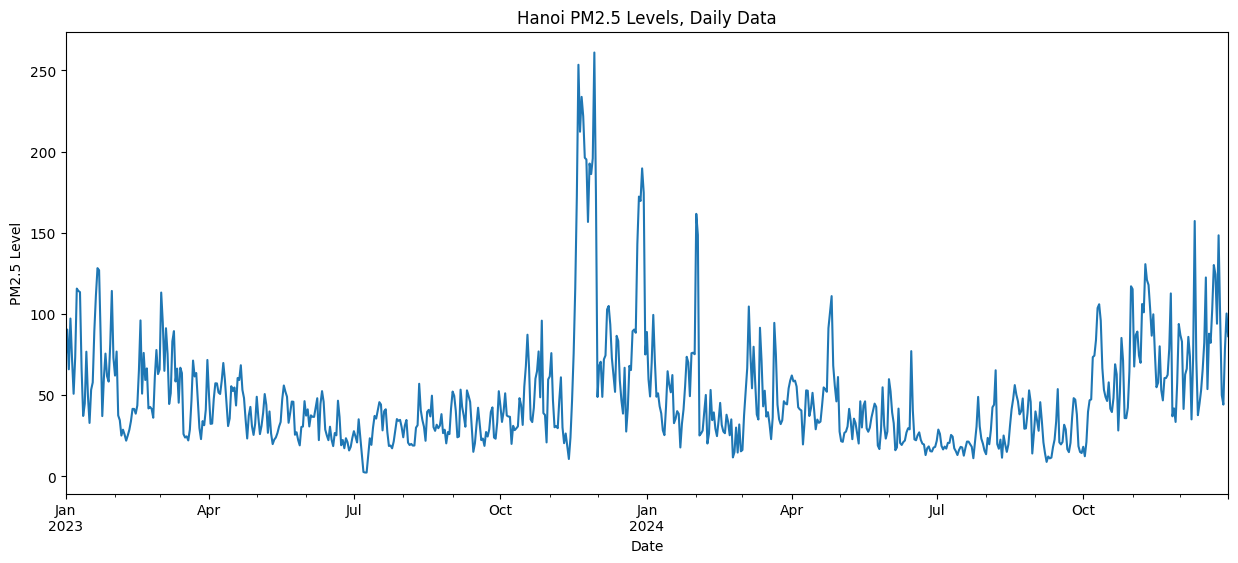

In [7]:

fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

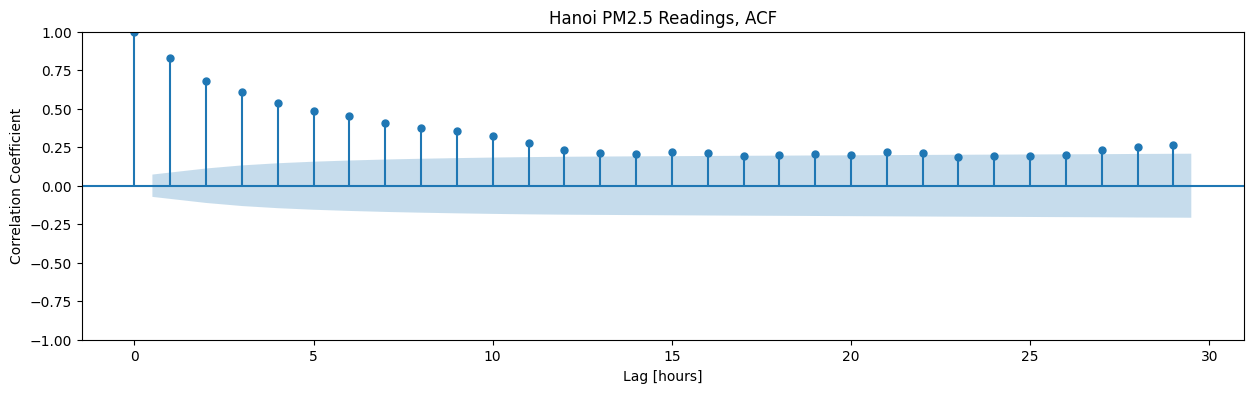

In [25]:

fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

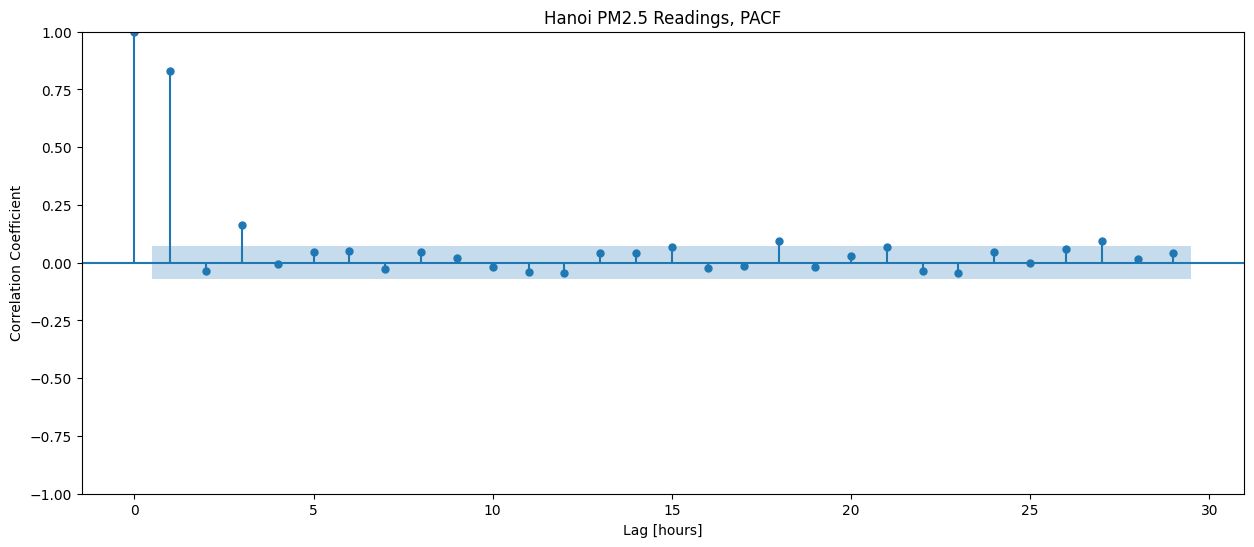

In [28]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

In [10]:
int(len(df_pm25)) *0.8

584.8000000000001

In [11]:
cutoff_test = int(len(df_pm25)* 0.8) 
df_pm25_train = df_pm25.iloc[:cutoff_test]
df_pm25_test = df_pm25.iloc[cutoff_test:]
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)

df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


In [12]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.830512605524053
p-value: 3.985322860994825e-07
Critical Values: {'1%': np.float64(-3.4416553818946145), '5%': np.float64(-2.8665274458710064), '10%': np.float64(-2.5694261699959413)}


In [13]:
df_pm25_train_mean = df_pm25_train.mean()
df_pm25_pred_baseline = [df_pm25_train_mean]*len(df_pm25_train)
mae_baseline = mean_absolute_error(df_pm25_train, df_pm25_pred_baseline)

print("Mean P2 Reading:", round(df_pm25_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 47.51
Baseline MAE: 22.86


In [14]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

In [29]:

# Create dictionary to store MAEs
mae_grid = dict()
# Outer loop: Iterate through possible values for `p`
for p in p_params:
    # Create key-value pair in dict. Key is `p`, value is empty list.
    mae_grid[p] = list()
    # Inner loop: Iterate through possible values for `q`
    for q in q_params:
        # Combination of hyperparameters for model
        order = (p, 0, q)
        # Note start time
        start_time = time.time()
        # Train model
        model = ARIMA(df_pm25_train, order=order).fit()
        # Calculate model training time
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        df_pm25_pred = model.predict()
        # Calculate training MAE
        mae = mean_absolute_error(df_pm25_train, df_pm25_pred)
        # Append MAE to list in dictionary
        mae_grid[p].append(mae)

print()
print(mae_grid)


Trained ARIMA (0, 0, 0) in 0.06 seconds.
Trained ARIMA (0, 0, 1) in 0.05 seconds.
Trained ARIMA (0, 0, 2) in 0.09 seconds.
Trained ARIMA (1, 0, 0) in 0.06 seconds.
Trained ARIMA (1, 0, 1) in 0.1 seconds.
Trained ARIMA (1, 0, 2) in 0.11 seconds.
Trained ARIMA (2, 0, 0) in 0.03 seconds.


c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (2, 0, 1) in 0.14 seconds.
Trained ARIMA (2, 0, 2) in 0.26 seconds.
Trained ARIMA (3, 0, 0) in 0.07 seconds.
Trained ARIMA (3, 0, 1) in 0.16 seconds.
Trained ARIMA (3, 0, 2) in 0.63 seconds.
Trained ARIMA (4, 0, 0) in 0.16 seconds.
Trained ARIMA (4, 0, 1) in 0.31 seconds.


c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (4, 0, 2) in 0.73 seconds.
Trained ARIMA (5, 0, 0) in 0.18 seconds.
Trained ARIMA (5, 0, 1) in 0.51 seconds.


c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (5, 0, 2) in 0.8 seconds.
Trained ARIMA (6, 0, 0) in 0.31 seconds.
Trained ARIMA (6, 0, 1) in 0.36 seconds.
Trained ARIMA (6, 0, 2) in 0.88 seconds.
Trained ARIMA (7, 0, 0) in 0.35 seconds.
Trained ARIMA (7, 0, 1) in 0.53 seconds.
Trained ARIMA (7, 0, 2) in 0.94 seconds.

{0: [22.856964405763712, 16.289556774378354, 14.388829776628583], 1: [12.497772757104551, 12.500306408935135, 12.335218851839986], 2: [12.495287388611326, 12.452083272869881, 12.342459801095766], 3: [12.339681299841267, 12.362172933259703, 12.334534407489873], 4: [12.368695287387077, 12.367253682184439, 12.31828196172769], 5: [12.3425486816015, 12.313040784646542, 12.183180589890059], 6: [12.311235028212462, 12.274237944093569, 12.288689614851112], 7: [12.299426509831177, 12.274976516563068, 12.27667839201213]}


In [30]:
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,1,2,3,4,5,6,7
0,22.8570,12.4978,12.4953,12.3397,12.3687,12.3425,12.3112,12.2994
1,16.2896,12.5003,12.4521,12.3622,12.3673,12.3130,12.2742,12.2750
2,14.3888,12.3352,12.3425,12.3345,12.3183,12.1832,12.2887,12.2767


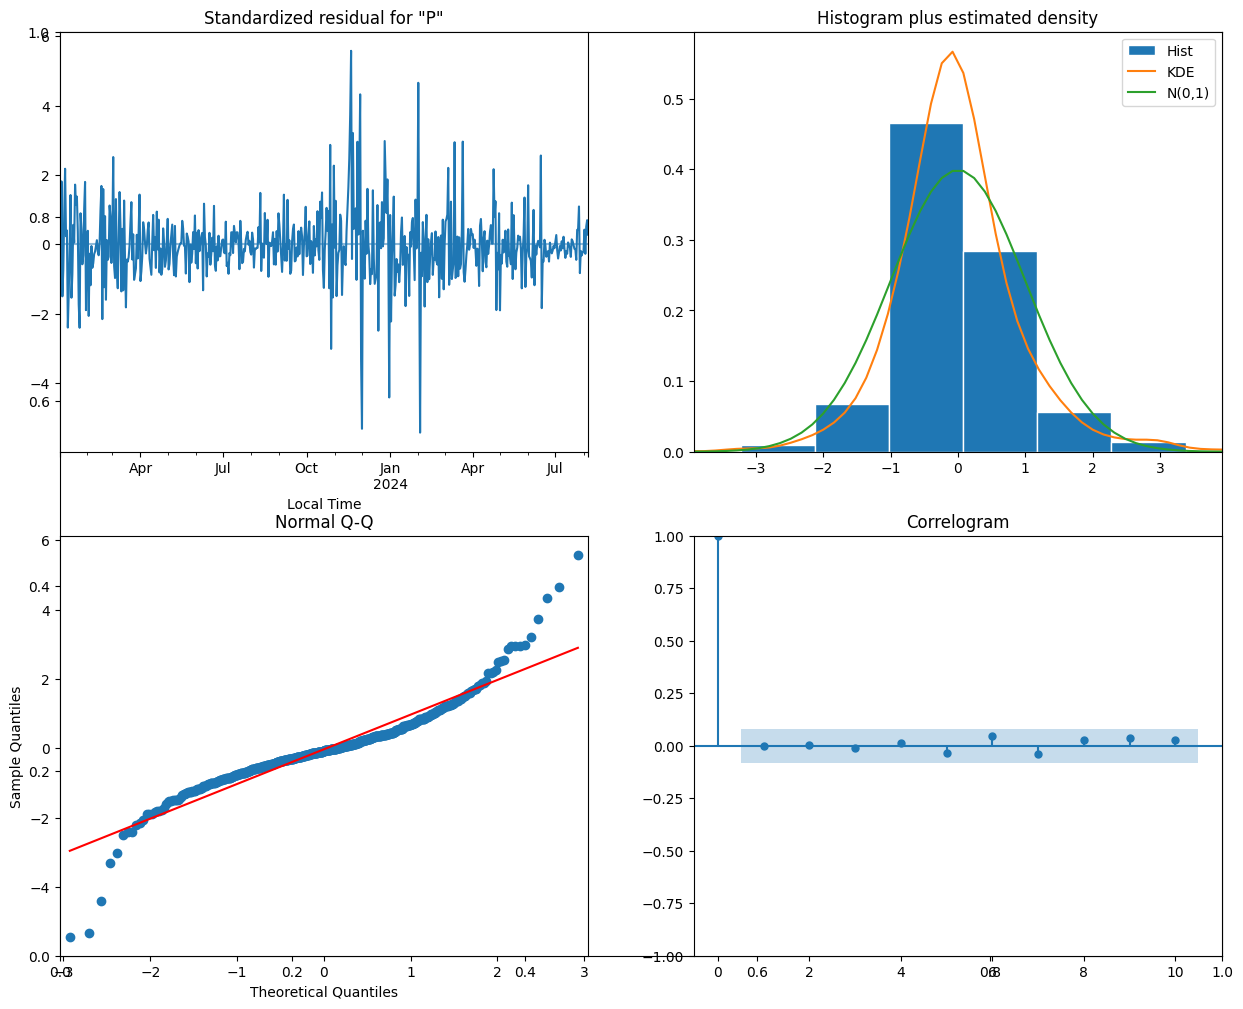

In [31]:
model = ARIMA(df_pm25_train, order=(5,1,1))
results = model.fit()
fig, ax = plt.subplots(figsize=(15, 12))
results.plot_diagnostics(fig=fig)
# Save the plot as an image file (e.g., PNG)
plt.savefig('example_plot.png')

In [18]:
df_pm25_pred_wfv = pd.Series()  # Initialize as an empty Series instead of a list
history = df_pm25_train.copy()
for i in range(len(df_pm25_test)):
    model = ARIMA(history, order = (5, 1, 1)).fit()
    next_pred = model.forecast()
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    # Round the entire Series to 2 decimals
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    history = pd.concat([history, df_pm25_test[next_pred.index]])

C:\Users\hungd\AppData\Local\Temp\ipykernel_19372\1733131424.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])


In [19]:

df_pm25_pred_wfv

2024-08-07    40.11
2024-08-08    60.76
2024-08-09    14.86
2024-08-10    24.81
2024-08-11    20.42
              ...  
2024-12-27    83.46
2024-12-28    62.74
2024-12-29    52.96
2024-12-30    79.90
2024-12-31    93.38
Freq: D, Length: 147, dtype: float64

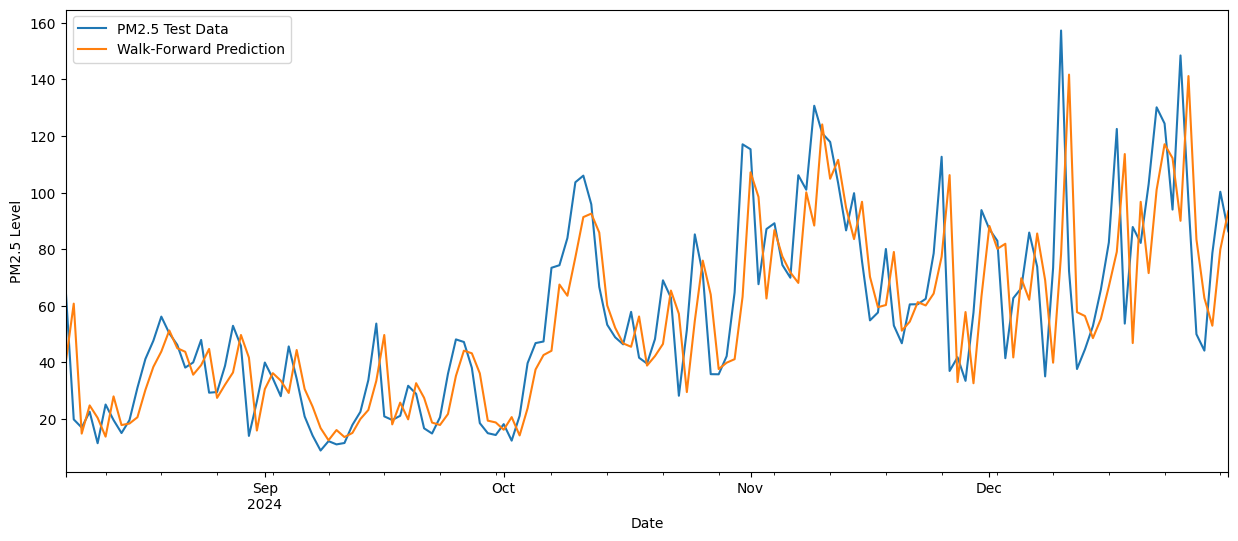

In [20]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()